**Configuration note:** this notebook examines the purge_dup results for Supplemental Figure S13. Input paths below mirror `config.sh` at the repo root — edit them for your own data. The primary input is `dups.bed` (purge_dups output: HAPLOTIG / HIGHCOV / JUNK / OVLP / REPEAT).


In [ ]:
# Input paths — edit for your environment (mirror config.sh at the repo root).
PROJ_ROOT = "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj"
DUP_BED   = f"{PROJ_ROOT}/output/outputs-from-purge-duplicate/hifiasm-041425-scaffolded-assembly/dups.bed"


# Quantify the amount of 2nd round of additonal dup purging in our assembly 
Format the figure like figure 8 from 2022 paper: https://link.springer.com/article/10.1186/s13059-022-02764-1#MOESM8

In [1]:
library(tidyverse)
library(ggrepel)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
## Read in fai file of scaffolded and curated assembly
fai = "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/data/denovo_OctDegus_genome/041425-assembly/hifiasm-041425-assembly-mitoFiltered-scaffolded-curated-masked-chrNameAssigned/assembly_final.sorted.headerRenamed.chrAssigned.fasta.fai"
chrom <- read.table(fai)
colnames(chrom)<-c("chrom","length","v1","v2","v3")

In [3]:
head(chrom)

,chrom,length,v1,v2,v3
,<chr>,<int>,<dbl>,<int>,<int>
1,chr1,185300982,6,60,61
2,chr2,158109495,188389344,60,61
3,chr3,152493930,349134004,60,61
4,chr4,151562733,504169506,60,61
5,chr5,142911117,658258291,60,61
6,chr6,138704743,803551266,60,61


In [4]:
dup_bed = "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/output/outputs-from-purge-duplicate/hifiasm-041425-scaffolded-assembly/dups.bed"
dup_info <- read.table(dup_bed,
                       header = FALSE, 
                       fill = TRUE, 
                       sep = "\t", 
                       stringsAsFactors = FALSE)

In [5]:
head(dup_info)

,V1,V2,V3,V4,V5
,<chr>,<int>,<int>,<chr>,<chr>
1,chr19,0,14581,HAPLOTIG,chr19
2,chr19,14682,48677,HIGHCOV,
3,chr19,48778,83854,HIGHCOV,
4,chr19,83954,117147,HAPLOTIG,chr19
5,chr19,117247,3413394,REPEAT,chr19
6,chr19,97691919,98060106,REPEAT,chr19


In [6]:
# ============================================================================
# Build a mapping dataframe that links chromosome/scaffold names across three
# assembly stages. We match by sequence length, which is unique for 286 of the
# 288 scaffolds. Two scaffolds (PGA_scaffold_262 and PGA_scaffold_263) share
# the same length (10,796 bp) — for those we disambiguate by sequence identity
# (verified via samtools faidx): their seq2/seq3 names are swapped relative to
# seq1 numbering.
#
# seq1 — scaffolded & curated (before masking)
# seq2 — scaffolded, curated & masked
# seq3 — scaffolded, curated, masked & chromosome-name-assigned
# ============================================================================

seq1 <- read.table("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/data/denovo_OctDegus_genome/041425-assembly/hifiasm-041425-assembly-mitoFiltered-scaffolded-curated/assembly_final.fasta.fai")
seq2 <- read.table("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/data/denovo_OctDegus_genome/041425-assembly/hifiasm-041425-assembly-mitoFiltered-scaffolded-curated-masked/assembly_final.sorted.headerRenamed.fasta.masked.fai")
seq3 <- read.table("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/data/denovo_OctDegus_genome/041425-assembly/hifiasm-041425-assembly-mitoFiltered-scaffolded-curated-masked-chrNameAssigned/assembly_final.sorted.headerRenamed.chrAssigned.fasta.fai")

# Give each table descriptive column names (fai format: name, length, offset, linebases, linewidth)
colnames(seq1) <- c("scaffold_name",   "length", "v3", "v4", "v5")
colnames(seq2) <- c("masked_name",     "length", "v3", "v4", "v5")
colnames(seq3) <- c("chr_assigned_name","length", "v3", "v4", "v5")

# ---- Step 1: Join seq1 → seq2 by length ----
# For the one duplicate length (10796) this creates a cartesian product.
mapping_df <- seq1 %>%
  select(scaffold_name, length) %>%
  left_join(seq2 %>% select(masked_name, length), by = "length",
            relationship = "many-to-many")

# ---- Step 2: Fix the length-10796 duplicate for seq1→seq2 ----
# Verified by samtools faidx: PGA_scaffold_262 sequence = seq263, and
# PGA_scaffold_263 sequence = seq262 (names got swapped during renaming).
mapping_df <- mapping_df %>%
  filter(!(
    length == 10796 &
    ((grepl("scaffold_262", scaffold_name) & masked_name == "seq262") |
     (grepl("scaffold_263", scaffold_name) & masked_name == "seq263"))
  ))
stopifnot(nrow(mapping_df) == 288)

# ---- Step 3: Join → seq3 by length (duplicate surfaces again) ----
mapping_df <- mapping_df %>%
  left_join(seq3 %>% select(chr_assigned_name, length), by = "length",
            relationship = "many-to-many")

# ---- Step 4: Fix the same duplicate for seq1→seq3 ----
mapping_df <- mapping_df %>%
  filter(!(
    length == 10796 &
    ((grepl("scaffold_262", scaffold_name) & chr_assigned_name == "seq262") |
     (grepl("scaffold_263", scaffold_name) & chr_assigned_name == "seq263"))
  ))

# ---- Step 5: Sanity checks ----
stopifnot(nrow(mapping_df) == 288)
stopifnot(length(unique(mapping_df$scaffold_name)) == 288)

head(mapping_df, 10)
print(dim(mapping_df))

,scaffold_name,length,masked_name,chr_assigned_name
,<chr>,<int>,<chr>,<chr>
1,PGA_scaffold_1__19_contigs__length_197914338,197914338,seq1,chrX
2,PGA_scaffold_2__14_contigs__length_185300982,185300982,seq2,chr1
3,PGA_scaffold_3__8_contigs__length_152493930,152493930,seq4,chr3
4,PGA_scaffold_4__9_contigs__length_151562733,151562733,seq5,chr4
5,PGA_scaffold_5__10_contigs__length_142911117,142911117,seq6,chr5
6,PGA_scaffold_6__1_contigs__length_82517476,82517476,seq25,chr23
7,PGA_scaffold_7__8_contigs__length_60231632,60231632,seq27,chr25
8,PGA_scaffold_8__5_contigs__length_138704743,138704743,seq7,chr6
9,PGA_scaffold_9__7_contigs__length_138367390,138367390,seq8,chr7


[1] 288   4


In [7]:
# Read FCS-GX contamination output
contam_mapping = "~/ps-renlab2-link/degu-genome-assembly-proj/code/command-line-script/assigning-chromosomes/contaminations/contamination_action.txt"
contam1 <- read.table(contam_mapping,
                      header = FALSE, 
                      fill = TRUE, 
                      sep = "\t", 
                      stringsAsFactors = FALSE)

# Read scaffold-to-contig lookup table
scaffold2contig <- read.table("~/ps-renlab2-link/degu-genome-assembly-proj/code/command-line-script/assigning-chromosomes/contaminations/scaffold2contig.tsv",
                               header = TRUE, row.names = 1,
                               stringsAsFactors = FALSE)

# ---- Extract contig name from V1 (strip "lcl|" prefix) ----
contam1$contig_name <- gsub("^lcl\\|", "", contam1$V1)

# ---- Map: contig → scaffold → final chromosome name ----
contam1 <- contam1 %>%
  left_join(scaffold2contig, by = "contig_name") %>%
  left_join(mapping_df %>% select(scaffold_name, chr_assigned_name),
            by = "scaffold_name")

head(contam1)
print(dim(contam1))

,V1,V2,V3,V4,V5,V6,V7,V8,contig_name,scaffold_name,chr_assigned_name
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,lcl|ptg000355l,1,58210,58210,EXCLUDE,anml:marsupials,50,Monodelphis domestica,ptg000355l,PGA_scaffold_121__1_contigs__length_58210,seq121
2,lcl|ptg000374l,1,128056,128056,EXCLUDE,prok:firmicutes,76,Atopostipes suicloacalis,ptg000374l,PGA_scaffold_71__1_contigs__length_128056,seq71
3,lcl|ptg000375l,1,384888,384888,EXCLUDE,prok:firmicutes,93,Atopostipes suicloacalis,ptg000375l,PGA_scaffold_40__1_contigs__length_384888,seq40
4,lcl|ptg000377l,1,13139,13139,EXCLUDE,prok:g-proteobacteria,100,Psychrobacter sp. UBA2071,ptg000377l,PGA_scaffold_241__1_contigs__length_13139,seq241
5,lcl|ptg000378l,1,31351,31351,EXCLUDE,prok:firmicutes,76,Atopostipes suicloacalis,ptg000378l,PGA_scaffold_183__1_contigs__length_31351,seq183
6,lcl|ptg000379l,1,432515,432515,EXCLUDE,prok:firmicutes,83,Atopostipes suicloacalis,ptg000379l,PGA_scaffold_35__1_contigs__length_432515,seq35


[1] 90 11


In [8]:
# ============================================================================
# Build contamination plot dataframe — one row per (chrom, V6 category) with
# the percentage of each scaffold's total length that falls in that category.
# ============================================================================

contam_plot_df <- contam1 %>%
  filter(!is.na(chr_assigned_name)) %>%
  group_by(chr_assigned_name, V6) %>%
  summarise(
    contig_len_sum = sum(V4, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  left_join(
    chrom %>% select(chr_assigned_name = chrom, scaffold_len = length),
    by = "chr_assigned_name"
  ) %>%
  mutate(
    percent = contig_len_sum / scaffold_len * 100
  )

head(contam_plot_df)
print(dim(contam_plot_df))

chr_assigned_name,V6,contig_len_sum,scaffold_len,percent
<chr>,<chr>,<int>,<int>,<dbl>
seq103,prok:firmicutes,70767,70767,100
seq111,prok:firmicutes,66007,66007,100
seq121,anml:marsupials,58210,58210,100
seq141,prok:firmicutes,47751,47751,100
seq144,prok:g-proteobacteria,46298,46298,100
seq146,prok:firmicutes,45828,45828,100


[1] 90  5


In [9]:
unique(contam1$V6)

[1] "anml:marsupials"       "prok:firmicutes"       "prok:g-proteobacteria"
[4] "prok:spirochetes"

In [10]:
chrom <- chrom %>% arrange(desc(length))
chrom$length <- factor(chrom$length, levels = unique(chrom$length))

In [11]:
library(ggplot2)
library(dplyr)
library(forcats)

plot_df <- chrom %>%
  mutate(
    # Convert factor safely to numeric
    length = as.numeric(as.character(length)),

    scaffold_type = if_else(
      grepl("^chr([0-9]+|X|Y)$", chrom),
      "Chromosome",
      "Unplaced scaffold"
    ),

    sqrt_length = sqrt(length),

    # Order scaffolds by length, with the longest at the top
    chrom_plot = fct_reorder(chrom, length)
  ) %>%
  filter(!is.na(length), length > 0)



In [12]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(patchwork)
library(scales)
library(ggrepel)

# ============================================================================
# 1. Scaffold lengths
# ============================================================================

scaffold_info <- plot_df %>%
  transmute(
    chrom = as.character(chrom),
    scaffold_length = as.numeric(as.character(length)),
    scaffold_type = as.character(scaffold_type),
    sqrt_length = sqrt_length
  ) %>%
  distinct(chrom, .keep_all = TRUE)


# ============================================================================
# 2. Create dup_plot_df directly from dup_info
#
# dup_info columns:
# V1 = scaffold/chromosome
# V2 = BED start
# V3 = BED end
# V4 = purge_dups category
# ============================================================================

dup_bp <- dup_info %>%
  transmute(
    chrom = as.character(V1),
    start = as.numeric(V2),
    end = as.numeric(V3),
    feature = as.character(V4),
    bp = end - start
  ) %>%
  filter(
    !is.na(chrom),
    !is.na(feature),
    !is.na(bp),
    bp > 0
  ) %>%
  group_by(chrom, feature) %>%
  summarise(
    bp = sum(bp),
    .groups = "drop"
  )


# Categories actually present in the purge_dups BED
purge_features <- sort(unique(dup_bp$feature))


# Add zero values for scaffold/category combinations absent from the BED
dup_complete <- expand_grid(
  chrom = scaffold_info$chrom,
  feature = purge_features
) %>%
  left_join(
    dup_bp,
    by = c("chrom", "feature")
  ) %>%
  mutate(
    bp = replace_na(bp, 0)
  ) %>%
  left_join(
    scaffold_info %>%
      select(chrom, scaffold_length),
    by = "chrom"
  )


# Calculate sequence not classified by purge_dups
retained_df <- dup_complete %>%
  group_by(chrom, scaffold_length) %>%
  summarise(
    classified_bp = sum(bp, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  transmute(
    chrom,
    scaffold_length,
    feature = "Retained",
    bp = pmax(scaffold_length - classified_bp, 0)
  )


# Final stacked-bar dataframe
dup_plot_df <- dup_complete %>%
  select(
    chrom,
    scaffold_length,
    feature,
    bp
  ) %>%
  bind_rows(retained_df) %>%
  mutate(
    percent = 100 * bp / scaffold_length,

    feature = factor(
      feature,
      levels = c(
        "Retained",
        "REPEAT",
        "HIGHCOV",
        "HAPLOTIG",
        "JUNK",
        "OVLP",
        setdiff(
          purge_features,
          c(
            "REPEAT",
            "HIGHCOV",
            "HAPLOTIG",
            "JUNK",
            "OVLP"
          )
        )
      )
    )
  )


# ============================================================================
# 3. Give every scaffold one shared numeric y-position
# ============================================================================

scaffold_positions <- scaffold_info %>%
  arrange(desc(scaffold_length)) %>%
  mutate(
    y_position = n() - row_number() + 1
  )

n_scaffolds <- nrow(scaffold_positions)

position_lookup <- scaffold_positions %>%
  select(chrom, y_position)


# Add y-position to the scaffold-length dataframe
plot_df_aligned <- plot_df %>%
  mutate(
    chrom = as.character(chrom)
  ) %>%
  select(-any_of("y_position")) %>%
  left_join(
    position_lookup,
    by = "chrom"
  ) %>%
  filter(!is.na(y_position))


# Add y-position to purge_dups dataframe
dup_plot_df_aligned <- dup_plot_df %>%
  mutate(
    chrom = as.character(chrom)
  ) %>%
  select(-any_of("y_position")) %>%
  left_join(
    position_lookup,
    by = "chrom"
  ) %>%
  filter(!is.na(y_position))


# ============================================================================
# 4. Add y-position to contamination dataframe
# ============================================================================

contam_plot_df_aligned <- contam_plot_df %>%
  mutate(
    chrom = as.character(chr_assigned_name)
  ) %>%
  select(-any_of("y_position")) %>%
  left_join(
    position_lookup,
    by = "chrom"
  ) %>%
  filter(!is.na(y_position))


# ============================================================================
# 5. Annotate chromosomes with >10% non-retained purge_dups sequence
# ============================================================================

chromosome_annotations <- dup_plot_df_aligned %>%
  filter(
    !is.na(feature),
    as.character(feature) != "Retained"
  ) %>%
  group_by(chrom, y_position) %>%
  summarise(
    purge_percent = sum(percent, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  left_join(
    scaffold_info %>%
      select(chrom, scaffold_type),
    by = "chrom"
  ) %>%
  filter(
    scaffold_type == "Chromosome",
    purge_percent > 10
  ) %>%
  mutate(
    annotation_label = sprintf(
      "%s (%.1f%%)",
      chrom,
      purge_percent
    ),

    # Anchor the annotation immediately after the colored portion
    label_x = purge_percent + 1
  )

chromosome_annotations


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




chrom,y_position,purge_percent,scaffold_type,annotation_label,label_x
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
chr18,270,15.06857,Chromosome,chr18 (15.1%),16.06857
chr2,286,20.08650,Chromosome,chr2 (20.1%),21.08650
chr21,267,15.55296,Chromosome,chr21 (15.6%),16.55296
chr25,262,16.68838,Chromosome,chr25 (16.7%),17.68838
chr4,284,14.89025,Chromosome,chr4 (14.9%),15.89025
chrY,266,18.66665,Chromosome,chrY (18.7%),19.66665


In [13]:

# ============================================================================
# Left panel: scaffold lengths
# ============================================================================

p <- ggplot(
  plot_df_aligned,
  aes(
    x = sqrt_length,
    y = y_position,
    fill = scaffold_type
  )
) +
  geom_col(
    width = 0.82,
    linewidth = 0,
    orientation = "y"
  ) +

  scale_x_reverse(
    name = "Length of scaffold (SQRT)",
    expand = expansion(mult = c(0.03, 0))
  ) +

  # These exact limits are also used in the right panel
  scale_y_continuous(
    limits = c(0.5, n_scaffolds + 0.5),
    breaks = NULL,
    expand = expansion(mult = 0)
  ) +

  scale_fill_manual(
    values = c(
      "Chromosome" = "#F8766D",
      "Unplaced scaffold" = "#27BFC0"
    ),
    breaks = c(
      "Chromosome",
      "Unplaced scaffold"
    ),
  guide = guide_legend(
    ncol = 1,
    byrow = TRUE
  )
  ) +

  labs(
    y = NULL,
    fill = NULL
  ) +

  theme_classic(base_size = 11) +
  theme(
    legend.position = "top",
    legend.justification = "center",
    legend.direction = "vertical",
    
    legend.text = element_text(size = 9),
    
    legend.key.width = unit(0.45, "cm"),
    legend.key.height = unit(0.38, "cm"),
    
    legend.spacing.x = unit(0.10, "cm"),
    legend.box.spacing = unit(0.12, "cm"),
    panel.border = element_rect(
      color = "grey40",
      fill = NA,
      linewidth = 0.6
    ),

    axis.line = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.y = element_blank(),
    axis.text.x = element_text(size = 9),

    axis.title.x = element_text(
      face = "bold",
      margin = margin(t = 6)
    ),

    # Very small right margin so the panels sit close together
plot.margin = margin(
  t = 2,
  r = 8,
  b = 5.5,
  l = 3
)
  )


chrom,y_position,purge_percent,scaffold_type,annotation_label,label_x,label_y,label_x_fixed
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
chr2,286,20.08650,Chromosome,chr2 (20.1%),21.08650,287,25.0865
chr4,284,14.89025,Chromosome,chr4 (14.9%),15.89025,283,25.0865
chr18,270,15.06857,Chromosome,chr18 (15.1%),16.06857,272,25.0865
chr21,267,15.55296,Chromosome,chr21 (15.6%),16.55296,268,25.0865
chrY,266,18.66665,Chromosome,chrY (18.7%),19.66665,264,25.0865
chr25,262,16.68838,Chromosome,chr25 (16.7%),17.68838,262,25.0865


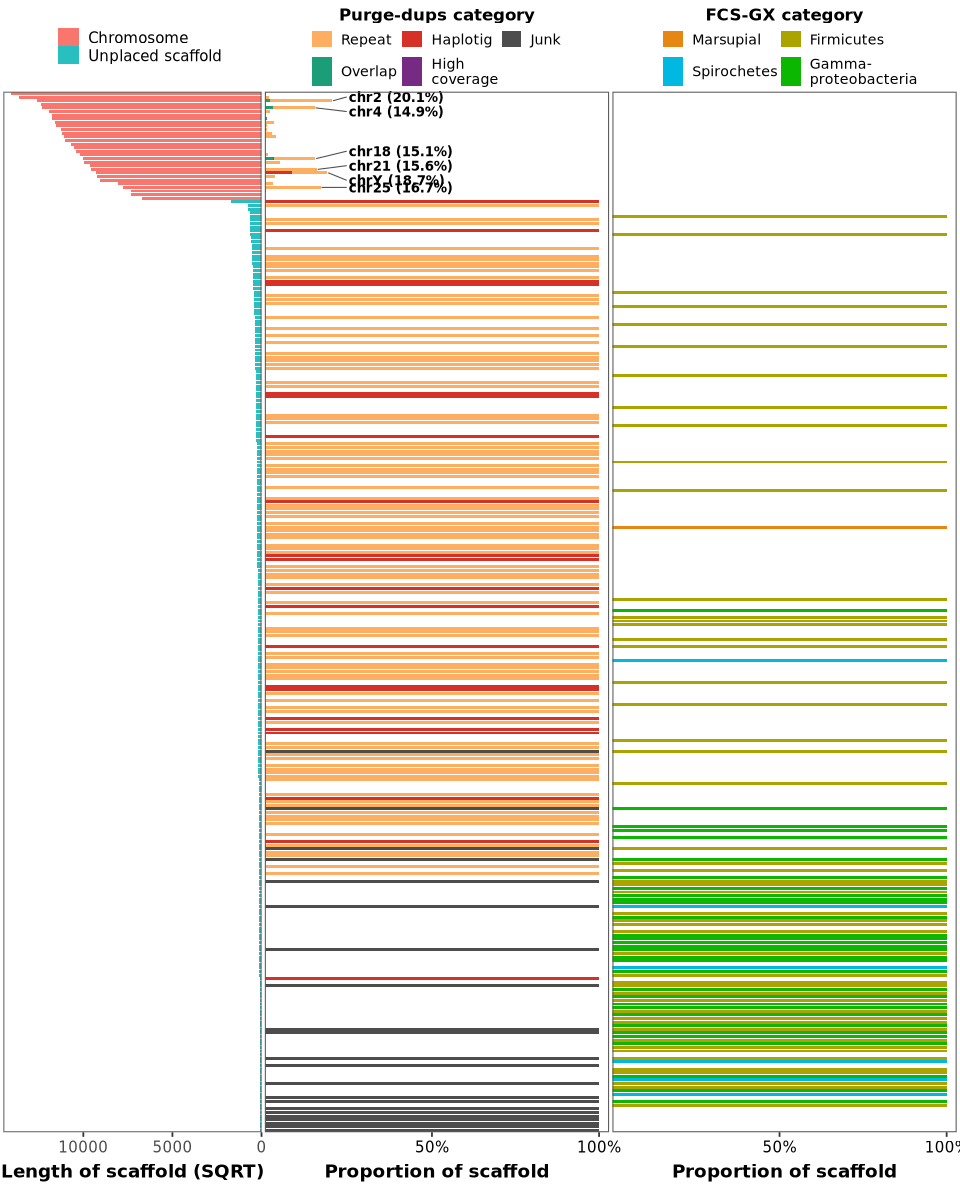

In [33]:
library(ggrepel)
library(tidyr)
library(grid)

# ============================================================================
# Shared formatting for both percentage panels
# ============================================================================

category_x_scale <- function() {
  scale_x_continuous(
    name = "Proportion of scaffold",
    limits = c(0, 100),
    breaks = c(50, 100),
    labels = c("50%", "100%"),

    # Prevent the 100% label from being clipped
    expand = expansion(add = c(0, 3))
  )
}

category_y_scale <- function() {
  scale_y_continuous(
    limits = c(0.5, n_scaffolds + 0.5),
    breaks = NULL,
    expand = expansion(mult = c(0, 0))
  )
}

category_legend <- function(title) {
  guide_legend(
    title = title,
    title.position = "top",
    title.hjust = 0.5,
    nrow = 2,
    byrow = TRUE
  )
}

category_panel_theme <- theme_classic(base_size = 11) +
  theme(
    legend.position = "top",
    legend.justification = "center",
    legend.direction = "horizontal",
    legend.box = "vertical",

    legend.title = element_text(
      size = 10,
      face = "bold",
      hjust = 0.5
    ),

    legend.text = element_text(
      size = 8.5,
      lineheight = 0.9
    ),

    legend.key.width = unit(0.42, "cm"),
    legend.key.height = unit(0.34, "cm"),

    legend.spacing.x = unit(0.08, "cm"),
    legend.spacing.y = unit(0.04, "cm"),
    legend.box.spacing = unit(0.10, "cm"),
    legend.margin = margin(0, 0, 0, 0),

    panel.border = element_rect(
      color = "grey35",
      fill = NA,
      linewidth = 0.6
    ),

    axis.line = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.y = element_blank(),

    axis.text.x = element_text(
      size = 9,
      color = "black"
    ),

    axis.title.x = element_text(
      size = 11,
      face = "bold",
      margin = margin(t = 6)
    ),

    plot.margin = margin(
      t = 2,
      r = 8,
      b = 5.5,
      l = 3
    )
  )


# ============================================================================
# Middle panel: purge_dups percentages
# High coverage moved to the end
# ============================================================================

purge_colors <- c(
  "REPEAT"   = "#FDAE61",
  "HAPLOTIG" = "#D73027",
  "JUNK"     = "#4D4D4D",
  "OVLP"     = "#1B9E77",
  "HIGHCOV"  = "#762A83"
)

dup_plot_df_display <- dup_plot_df_aligned %>%
  filter(
    !is.na(feature),
    as.character(feature) != "Retained"
  ) %>%
  mutate(
    feature = factor(
      as.character(feature),
      levels = c(
        "REPEAT",
        "HAPLOTIG",
        "JUNK",
        "OVLP",
        "HIGHCOV"
      )
    )
  )

# ============================================================================
# Position chromosome annotations without changing their vertical order
# ============================================================================

spread_labels_in_order <- function(y, min_gap = 4) {

  # Work from top to bottom
  ord <- order(y, decreasing = TRUE)
  y_sorted <- y[ord]

  if (length(y_sorted) <= 1) {
    return(y)
  }

  # Labels separated by less than min_gap belong to the same cluster
  gaps <- y_sorted[-length(y_sorted)] - y_sorted[-1]

  cluster <- c(
    1L,
    1L + cumsum(gaps >= min_gap)
  )

  adjusted <- numeric(length(y_sorted))

  for (g in unique(cluster)) {

    idx <- which(cluster == g)
    n_group <- length(idx)

    # Center each cluster around its original positions
    cluster_center <- mean(range(y_sorted[idx]))

    offsets <- (
      (n_group - 1) / 2 -
      (seq_len(n_group) - 1)
    ) * min_gap

    adjusted[idx] <- cluster_center + offsets
  }

  # Return values in the original row order
  output <- numeric(length(y))
  output[ord] <- adjusted

  output
}


# Put all chromosome labels in one clean annotation column
annotation_x <- max(
  chromosome_annotations$purge_percent,
  na.rm = TRUE
) + 5


chromosome_annotations_plot <- chromosome_annotations %>%
  arrange(desc(y_position)) %>%
  mutate(
    label_y = spread_labels_in_order(
      y_position,
      min_gap = 4
    ),

    label_x_fixed = annotation_x
  )

chromosome_annotations_plot

p_dup <- ggplot(
  dup_plot_df_display,
  aes(
    x = percent,
    y = y_position,
    fill = feature
  )
) +
  geom_col(
    width = 0.82,
    linewidth = 0,
    orientation = "y"
  ) +

# Connector lines
geom_segment(
  data = chromosome_annotations_plot,
  aes(
    x = purge_percent + 0.4,
    xend = label_x_fixed - 0.7,
    y = y_position,
    yend = label_y
  ),
  inherit.aes = FALSE,
  color = "grey30",
  linewidth = 0.3,
  lineend = "round"
) +

# Aligned chromosome labels
geom_text(
  data = chromosome_annotations_plot,
  aes(
    x = label_x_fixed,
    y = label_y,
    label = annotation_label
  ),
  inherit.aes = FALSE,
  hjust = 0,
  size = 2.8,
  fontface = "bold",
  color = "black"
) +

  category_x_scale() +
  category_y_scale() +

  scale_fill_manual(
    values = purge_colors,
    breaks = c(
      "REPEAT",
      "HAPLOTIG",
      "JUNK",
      "OVLP",
      "HIGHCOV"
    ),
    labels = c(
      "Repeat",
      "Haplotig",
      "Junk",
      "Overlap",
      "High\ncoverage"
    ),
    drop = FALSE,
    guide = category_legend("Purge-dups category")
  ) +

  labs(
    x = "Proportion of scaffold",
    y = NULL
  ) +

  category_panel_theme


# ============================================================================
# Prepare contamination data
# Gamma-proteobacteria moved to the end
# ============================================================================

contam_plot_df_display <- contam_plot_df_aligned %>%
  transmute(
    chrom = as.character(chrom),
    y_position,
    feature = as.character(V6),
    percent = as.numeric(percent)
  ) %>%
  filter(
    !is.na(feature),
    !is.na(percent),
    percent > 0
  ) %>%
  group_by(
    chrom,
    y_position,
    feature
  ) %>%
  summarise(
    percent = sum(percent),
    .groups = "drop"
  ) %>%
  mutate(
    feature = factor(
      feature,
      levels = c(
        "anml:marsupials",
        "prok:firmicutes",
        "prok:spirochetes",
        "prok:g-proteobacteria"
      )
    )
  )


# ============================================================================
# Right panel: contamination categories
# ============================================================================

contam_colors <- c(
  "anml:marsupials"        = "#E68613",
  "prok:firmicutes"        = "#ABA300",
  "prok:spirochetes"       = "#00B8E0",
  "prok:g-proteobacteria"  = "#0CB702"
)

p_contam <- ggplot(
  contam_plot_df_display,
  aes(
    x = percent,
    y = y_position,
    fill = feature
  )
) +
  geom_col(
    width = 0.82,
    linewidth = 0,
    orientation = "y"
  ) +

  category_x_scale() +
  category_y_scale() +

  scale_fill_manual(
    values = contam_colors,
    breaks = c(
      "anml:marsupials",
      "prok:firmicutes",
      "prok:spirochetes",
      "prok:g-proteobacteria"
    ),
    labels = c(
      "Marsupial",
      "Firmicutes",
      "Spirochetes",
      "Gamma-\nproteobacteria"
    ),
    drop = FALSE,
    guide = category_legend("FCS-GX category")
  ) +

  labs(
    x = "Proportion of scaffold",
    y = NULL
  ) +

  category_panel_theme


# ============================================================================
# Combine aligned panels
# ============================================================================

options(
  repr.plot.width = 8,
  repr.plot.height = 10
)

combined_plot <- (p | p_dup | p_contam) +
  plot_layout(
    widths = c(1.5, 2, 2),
    guides = "keep"
  ) &
  theme(
    # Equal, small spacing on both sides of every panel
    plot.margin = margin(
      t = 2,
      r = 1,
      b = 5.5,
      l = 1,
      unit = "pt"
    )
  )

combined_plot


In [36]:
ggsave(
  filename = "scaffold_purge_dups_fcs_gx.pdf",
  plot = combined_plot,
  width = 8,
  height = 12,
  units = "in",
  device = cairo_pdf,
  bg = "white"
)


In [37]:
ggsave(
  filename = "scaffold_purge_dups_fcs_gx.svg",
  plot = combined_plot,
  width = 8,
  height = 12,
  units = "in",
  # device = cairo_pdf,
  bg = "white"
)


In [35]:
ggsave(
  filename = "scaffold_purge_dups_fcs_gx.png",
  plot = combined_plot,
  width = 8,
  height = 15,
  units = "in",
  dpi = 600,
  bg = "white"
)